# Grupo 1 | MCDI501 - Estadística Computacional para la Toma de Decisiones

## Integrantes
- Pablo Ignacio Balbontín Constenla @pabbalbontin-maker
- Melany Esmeralda Reyes Leiva @melanyreyesy
- Ingeborg Andrea Muñoz Carnot @dark452
- Mario Alejandro López Pulgar @malp2203

## Descripción del problema - Fase 4: Modelamiento Predictivo Integrado (Sumativa 3)

**Proyecto**: Predicción de la Deserción y el Éxito Académico de los Estudiantes

Este cuaderno integra los resultados de las Sumativas 1 y 2 en un modelo predictivo de
deserción estudiantil. El manejo de faltantes, la selección de variables, la lectura de la
colinealidad y la validación por bootstrap se fundamentan en los hallazgos de S1
(diagnóstico de calidad, correlaciones, pruebas de hipótesis) y S2 (correlaciones validadas
por bootstrap, pruebas confirmadas por permutación, observaciones influyentes por jackknife).

**Dataset:** *Predict Students' Dropout and Academic Success* (Realinho et al., 2022), UCI Repository.
$n = 4.424$ estudiantes, 37 variables.

**Estructura del cuaderno** (progresión S1 \$ \rightarrow \$ S2 \$ \rightarrow \$ S3 explícita en cada sección):

1. Manejo inteligente de datos faltantes
2. Clasificación mediante regresión logística
3. Análisis comparativo del impacto de la imputación
4. Síntesis integrada e informe final

**Semilla:** 42

## Configuración del entorno

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (confusion_matrix, roc_auc_score, roc_curve,
                             accuracy_score, precision_score, recall_score, f1_score)
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
SEED = 42
rng = np.random.default_rng(SEED)

plt.rcParams.update({'font.size': 10, 'figure.dpi': 120})
sns.set_style('whitegrid')

COLORS_TARGET = {'Graduate': '#2ca02c', 'Dropout': '#d62728', 'Enrolled': '#1f77b4'}
BOOT_COLOR = '#4c72b0'
PERM_COLOR = '#dd8452'
FIG_DIR = '../data/processed'

print('Entorno configurado.')

Entorno configurado.


In [2]:
def load_data(file_path):
    """Carga el dataset raw desde un archivo CSV.

    Parámetros
    ----------
    file_path : str
        Ruta del archivo CSV utilizado como entrada.

    Retorno
    -------
    pd.DataFrame
        Datos cargados en un DataFrame.

    Excepción
    ---------
    FileNotFoundError
        Si la ruta al archivo CSV no existe. Se muestra un mensaje de error.
    """
    try:
        df = pd.read_csv(file_path, sep=';')
    except FileNotFoundError:
        raise FileNotFoundError(
            f"No se encontro el archivo '{file_path}'. "
            "Verificar que el archivo CSV se encuentre en data/raw."
        )
    return df


df_full = load_data('../data/raw/predict_students_dropout_and_academic_success.csv')
df_full.columns = [c.strip() for c in df_full.columns]
print(f'Dataset cargado: {df_full.shape[0]:,} filas x {df_full.shape[1]} columnas')

Dataset cargado: 4,424 filas x 37 columnas


### Parámetros de referencia de las Sumativas 1 y 2

Los siguientes resultados, validados en la Sumativa 2 (sección 6, *"Preparación de insumos para la Sumativa 3"*), constituyen la base de las decisiones de modelamiento de esta fase.

In [3]:
# Correlaciones con el resultado académico validadas por bootstrap en S2 (IC 95%)
S2_CORR = {
    'Curricular units 2nd sem (grade)': {'lab': 'Nota 2do Semestre',    'r': 0.567, 'ci': (0.544, 0.589),   'clas': 'Robusta y relevante'},
    'Curricular units 1st sem (grade)': {'lab': 'Nota 1er Semestre',    'r': 0.485, 'ci': (0.461, 0.508),   'clas': 'Robusta y relevante'},
    'Age at enrollment':                {'lab': 'Edad al Matricularse', 'r': -0.243, 'ci': (-0.274, -0.213), 'clas': 'Robusta, relevancia moderada'},
    'Admission grade':                  {'lab': 'Nota de Admisión',     'r': 0.121, 'ci': (0.091, 0.150),   'clas': 'Robusta, relevancia baja'},
    'GDP':                              {'lab': 'PIB',                  'r': 0.044, 'ci': (0.016, 0.073),   'clas': 'Estable pero marginal'},
}

# Pruebas de hipótesis validadas por permutación en S2
S2_TESTS = {
    'Prueba 1': 'Nota de Admisión difiere entre Dropout y Graduate '
                '(Welch p=2.6e-14, permutación p=0.0001, Mann-Whitney p=3.3e-15)',
    'Prueba 2': 'Beca asociada al resultado académico '
                '(chi2 p=9.6e-90, permutación p=0.0001, V de Cramer=0.304)',
}

# Observaciones influyentes identificadas por jackknife en S2
S2_JACKKNIFE = ('Notas de admisión en el techo de escala (190) y estudiantes de 60-70 años, '
                'ningún caso altera las conclusiones al excluirlo.')

print('Referencias S1/S2 cargadas:')
for k, v in S2_CORR.items():
    print(f"  {v['lab']:<22} r={v['r']:+.3f}  IC=[{v['ci'][0]:+.3f}, {v['ci'][1]:+.3f}]  ({v['clas']})")
for k, v in S2_TESTS.items():
    print(f'  {k}: {v}')

Referencias S1/S2 cargadas:
  Nota 2do Semestre      r=+0.567  IC=[+0.544, +0.589]  (Robusta y relevante)
  Nota 1er Semestre      r=+0.485  IC=[+0.461, +0.508]  (Robusta y relevante)
  Edad al Matricularse   r=-0.243  IC=[-0.274, -0.213]  (Robusta, relevancia moderada)
  Nota de Admisión       r=+0.121  IC=[+0.091, +0.150]  (Robusta, relevancia baja)
  PIB                    r=+0.044  IC=[+0.016, +0.073]  (Estable pero marginal)
  Prueba 1: Nota de Admisión difiere entre Dropout y Graduate (Welch p=2.6e-14, permutación p=0.0001, Mann-Whitney p=3.3e-15)
  Prueba 2: Beca asociada al resultado académico (chi2 p=9.6e-90, permutación p=0.0001, V de Cramer=0.304)


### Definición del problema de clasificación

La variable objetivo original tiene tres clases (Graduate $49{,}9\%$ , Dropout $32{,}1\%$, Enrolled
$17{,}9\%$). Para el modelamiento se adopta el problema **binario Dropout (1) vs. Graduate (0)**,
excluyendo a los estudiantes Enrolled, por tres razones:

1. *Enrolled* no es un resultado terminal: son estudiantes aún matriculados al cierre del
   período, cuyo desenlace (graduarse o desertar) todavía no se observa, incluirlos como
   clase contaminaría el aprendizaje con etiquetas censuradas.
2. Toda la evidencia inferencial de S1 y S2 (pruebas de Welch, permutación y Mann-Whitney)
   se construyó comparando precisamente Dropout vs. Graduate, de modo que el modelo hereda
   directamente esas señales validadas.
3. La decisión de negocio que motiva el proyecto (intervención temprana de retención)
   requiere distinguir quién abandonará de quién se graduará.

In [4]:
df = df_full[df_full['Target'].isin(['Dropout', 'Graduate'])].copy()
df['y'] = (df['Target'] == 'Dropout').astype(int)
print(f'Subconjunto de modelamiento: {len(df):,} estudiantes')
print(f'  Graduate (0): {(df.y == 0).sum():,} ({(df.y == 0).mean() * 100:.1f}%)')
print(f'  Dropout  (1): {(df.y == 1).sum():,} ({df.y.mean() * 100:.1f}%)')
print('Desbalance moderado: no requiere ponderación de clases (a diferencia del caso')

Subconjunto de modelamiento: 3,630 estudiantes
  Graduate (0): 2,209 (60.9%)
  Dropout  (1): 1,421 (39.1%)
Desbalance moderado: no requiere ponderación de clases (a diferencia del caso


## Sección 1 - Manejo inteligente de datos faltantes

### 1.1 Referencia al análisis de faltantes de S1 y diagnóstico de faltantes ocultos

S1 reportó **cero valores faltantes explícitos** (ningún `NaN` en las 37 columnas). Sin
embargo, el diagnóstico de calidad de S1 (sección 1.3) dejó registrado el rango
`[0, 18.9]` de las notas semestrales, y una inspección más fina revela que el 0 no es una
nota real: en la escala portuguesa las notas de aprobación van de 10 a 20, y **todos** los
registros con nota semestral 0 tienen además 0 unidades curriculares aprobadas. Se trata de
**ceros estructurales**: estudiantes que no completaron evaluaciones en el semestre, para
quienes la nota promedio *no existe*. Codificarlos como 0 contamina la variable (mezcla
"no tiene nota" con "nota pésima") y distorsiona medias, correlaciones y coeficientes.

Siguiendo la práctica de manejo inteligente de faltantes, estos ceros estructurales se
recodifican como faltantes (`NaN`) y se tratan con las estrategias de imputación de esta
sección.

In [5]:
G1, G2 = 'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)'
A1, A2 = 'Curricular units 1st sem (approved)', 'Curricular units 2nd sem (approved)'

# ceros estructurales: nota 0 sin ninguna unidad aprobada
falt1 = (df[G1] == 0) & (df[A1] == 0)
falt2 = (df[G2] == 0) & (df[A2] == 0)
print('Faltantes ocultos (nota 0 con 0 unidades aprobadas):')
print(f'  Nota 1er semestre: {falt1.sum():,} ({falt1.mean() * 100:.1f}%)')
print(f'  Nota 2do semestre: {falt2.sum():,} ({falt2.mean() * 100:.1f}%)')
print(f'  Casos con nota 0 y aprobadas > 0 (inconsistencias): '
      f'{((df[G1] == 0) & (df[A1] > 0)).sum()}')

# evidencia sobre el mecanismo: el faltante se asocia a variables observadas
print('\nPerfil observado de los estudiantes con nota faltante (2do semestre):')
comp_vars = [('Tasa de deserción', df.loc[falt2, 'y'].mean(), df.loc[~falt2, 'y'].mean()),
             ('Matrícula al día', df.loc[falt2, 'Tuition fees up to date'].mean(),
              df.loc[~falt2, 'Tuition fees up to date'].mean()),
             ('Becado', df.loc[falt2, 'Scholarship holder'].mean(),
              df.loc[~falt2, 'Scholarship holder'].mean()),
             ('Deudor', df.loc[falt2, 'Debtor'].mean(), df.loc[~falt2, 'Debtor'].mean()),
             ('Edad promedio', df.loc[falt2, 'Age at enrollment'].mean(),
              df.loc[~falt2, 'Age at enrollment'].mean())]
print(f'{"Indicador":<20}{"Con faltante":>14}{"Sin faltante":>14}')
for lab, a, b in comp_vars:
    print(f'{lab:<20}{a:>14.3f}{b:>14.3f}')

# recodificacion como NaN
df.loc[falt1, G1] = np.nan
df.loc[falt2, G2] = np.nan
print(f'\nRecodificados como NaN => faltantes: {G1.split("(")[0].strip()}: '
      f'{int(df[G1].isna().sum())}, 2do sem: {int(df[G2].isna().sum())}')

Faltantes ocultos (nota 0 con 0 unidades aprobadas):
  Nota 1er semestre: 647 (17.8%)
  Nota 2do semestre: 802 (22.1%)
  Casos con nota 0 y aprobadas > 0 (inconsistencias): 0

Perfil observado de los estudiantes con nota faltante (2do semestre):
Indicador             Con faltante  Sin faltante
Tasa de deserción            0.906         0.245
Matrícula al día             0.676         0.920
Becado                       0.102         0.314
Deudor                       0.191         0.092
Edad promedio               26.108        22.710

Recodificados como NaN => faltantes: Curricular units 1st sem: 647, 2do sem: 802


**Verificación empírica: ¿es 0 una nota real o un centinela?** Antes de recodificar, se comprueba que el 0 no puede ser una nota reprobatoria genuina.

In [6]:
# (a) hueco en la distribucion: ninguna nota real cae entre 0 y la minima nota positiva
for g, lab in [(G1, '1er semestre'), (G2, '2do semestre')]:
    positivas = np.sort(df_full.loc[df_full[g] > 0, g].unique())
    print(f'Nota {lab}: minima nota positiva registrada = {positivas[0]:.2f} '
          f'=> ningun valor entre 0 y {positivas[0]:.2f} (hueco en la distribucion)')

# (b) estudiantes con nota 0 que igual se graduaron: imposible si 0 fuera nota real
sub_gd = df_full[df_full['Target'].isin(['Dropout', 'Graduate'])]
for g, lab in [(G1, '1er semestre'), (G2, '2do semestre')]:
    grad_cero = int(((sub_gd[g] == 0) & (sub_gd['Target'] == 'Graduate')).sum())
    print(f'Nota {lab} = 0 en estudiantes que se graduaron: {grad_cero} '
          f'(si 0 fuera nota reprobatoria real, graduarse con promedio 0 no seria posible)')

Nota 1er semestre: minima nota positiva registrada = 9.80 => ningun valor entre 0 y 9.80 (hueco en la distribucion)
Nota 2do semestre: minima nota positiva registrada = 10.00 => ningun valor entre 0 y 10.00 (hueco en la distribucion)
Nota 1er semestre = 0 en estudiantes que se graduaron: 77 (si 0 fuera nota reprobatoria real, graduarse con promedio 0 no seria posible)
Nota 2do semestre = 0 en estudiantes que se graduaron: 75 (si 0 fuera nota reprobatoria real, graduarse con promedio 0 no seria posible)


La verificación empírica anterior confirma que el 0 no es una nota reprobatoria genuina:
existe un hueco entre 0 y la nota positiva más baja ($9,80$ y $10,00$), y decenas de estudiantes
con nota 0 igualmente se graduaron ($77$ y $75$ casos), imposible si 0 fuera un promedio real.
El 0 es, en efecto, un centinela de 'sin evaluación', no un dato válido en la escala $0 - 20$.

**Diagnóstico del mecanismo.** De los tres mecanismos clásicos (Little & Rubin, 2019),
**MCAR** se descarta de inmediato: la ausencia de nota está fuertemente asociada al abandono
($90{,}6\%$ de deserción entre quienes no tienen nota del 2do semestre vs. $24{,}5\%$ entre quienes
sí la tienen) y a variables administrativas observadas (matrícula al día, deuda, beca,
edad). 
El mecanismo tiene además un componente **MNAR** irreducible: el estudiante no tiene
nota *porque* abandonó, es decir, la ausencia depende del propio desenlace. Adoptamos como
supuesto de trabajo el **MAR condicional**: la ausencia se explica por el desempeño y las
condiciones administrativas observadas (unidades aprobadas, matrícula al día, deuda, notas
previas), todas disponibles en el dataset. Es un supuesto, no una certeza, y lo declaramos
como tal, su implicancia práctica se evalúa empíricamente en la Sección 3, donde se
comparan las estrategias de manejo.

### 1.2 Imputación mediante regresión lineal múltiple

Los predictores de cada regresión se eligen con las correlaciones observadas en S1,
priorizando las que S2 validó como estables: la nota de admisión ($r = +0,34$ con la nota
del 1er semestre en casos completos), la nota de la titulación previa ($r = +0,30$), la edad
($r = −0,12$, dirección coherente con la correlación robusta de S2) y las unidades aprobadas
del semestre correspondiente, que es el indicador de desempeño observado para *todos* los
estudiantes, incluidos los que no tienen nota. Se ajusta sobre casos completos, se
verifican los supuestos con los residuos y se documenta el encogimiento de varianza propio
del método.

In [7]:
comp = df.dropna(subset=[G1, G2])
pred_g1 = ['Admission grade', 'Previous qualification (grade)', 'Age at enrollment', A1]
pred_g2 = ['Admission grade', 'Previous qualification (grade)', 'Age at enrollment', A2]

print('Correlaciones (casos completos) que justifican los predictores:')
print('  Nota 1er sem vs', {p.split('(')[0].strip(): round(np.corrcoef(comp[G1], comp[p])[0, 1], 3)
                            for p in pred_g1})
print('  Nota 2do sem vs', {p.split('(')[0].strip(): round(np.corrcoef(comp[G2], comp[p])[0, 1], 3)
                            for p in pred_g2})

lm1 = LinearRegression().fit(comp[pred_g1], comp[G1])
lm2 = LinearRegression().fit(comp[pred_g2], comp[G2])
pred = lm1.predict(comp[pred_g1])
resid = comp[G1].values - pred

print(f'\nAjuste: R2 nota 1er sem = {lm1.score(comp[pred_g1], comp[G1]):.3f} | '
      f'R2 nota 2do sem = {lm2.score(comp[pred_g2], comp[G2]):.3f}')
print('Verificación de supuestos (regresión de la nota del 1er semestre):')
print(f'  residuos: media = {resid.mean():.3f}, sd = {resid.std():.3f}, '
      f'asimetría = {stats.skew(resid):.2f}')
print(f'  corr(residuo, ajustado) = {np.corrcoef(resid, pred)[0, 1]:.3f} '
      '=> linealidad en media OK')
print(f'  encogimiento: sd(observado) = {comp[G1].std():.3f} vs sd(imputado) = '
      f'{pred.std():.3f} ({(1 - pred.std() / comp[G1].std()) * 100:.0f}% menos)')
print(f'  valores a imputar: 1er sem = {int(df[G1].isna().sum())}, '
      f'2do sem = {int(df[G2].isna().sum())}')

Correlaciones (casos completos) que justifican los predictores:
  Nota 1er sem vs {'Admission grade': np.float64(0.335), 'Previous qualification': np.float64(0.299), 'Age at enrollment': np.float64(-0.117), 'Curricular units 1st sem': np.float64(0.191)}
  Nota 2do sem vs {'Admission grade': np.float64(0.302), 'Previous qualification': np.float64(0.273), 'Age at enrollment': np.float64(-0.094), 'Curricular units 2nd sem': np.float64(0.302)}

Ajuste: R2 nota 1er sem = 0.166 | R2 nota 2do sem = 0.183
Verificación de supuestos (regresión de la nota del 1er semestre):
  residuos: media = -0.000, sd = 1.210, asimetría = 0.38
  corr(residuo, ajustado) = 0.000 => linealidad en media OK
  encogimiento: sd(observado) = 1.326 vs sd(imputado) = 0.540 (59% menos)
  valores a imputar: 1er sem = 647, 2do sem = 802


#### Figura 13. Imputación: encogimiento de varianza y diagnóstico de residuos

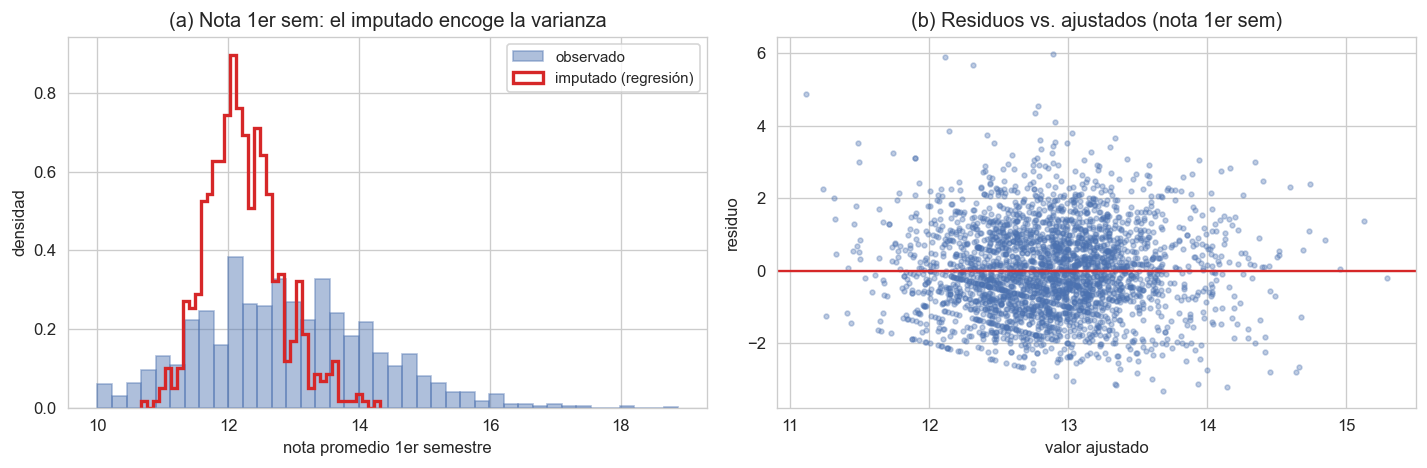

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

obs = comp[G1]
imp = np.clip(lm1.predict(df.loc[df[G1].isna(), pred_g1]), 0, 20)
ax[0].hist(obs, bins=40, color=BOOT_COLOR, alpha=0.45, density=True,
           edgecolor=BOOT_COLOR, label='observado')
ax[0].hist(imp, bins=40, color='#d62728', histtype='step', lw=2, density=True,
           label='imputado (regresión)')
ax[0].set_title('(a) Nota 1er sem: el imputado encoge la varianza')
ax[0].set_xlabel('nota promedio 1er semestre')
ax[0].set_ylabel('densidad')
ax[0].legend(fontsize=9)

ax[1].scatter(pred, resid, s=8, color=BOOT_COLOR, alpha=0.35)
ax[1].axhline(0, color='#d62728', lw=1.4)
ax[1].set_title('(b) Residuos vs. ajustados (nota 1er sem)')
ax[1].set_xlabel('valor ajustado')
ax[1].set_ylabel('residuo')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig13_imputacion.png', dpi=150, bbox_inches='tight')
plt.show()

Los residuos tienen media cero, no correlacionan con el valor ajustado (linealidad en
media razonable) y su asimetría es moderada ($0,38$). El ajuste es débil por construcción ($R² = 0,17$ y $0,18$): las notas
semestrales dependen de factores no observados (esfuerzo, asistencia), y las variables
pre-matrícula solo explican una fracción. La limitación más relevante es el
**encogimiento de varianza**: la regresión reemplaza cada faltante por su predicción
condicional, y los valores imputados tienen un $59\%$ menos de dispersión que los observados
(pico estrecho de la Figura 13a). Una imputación múltiple restauraría esa variabilidad;
lo asumimos como costo conocido del método y lo declaramos como limitación.

### 1.3 Comparación de estrategias de imputación

In [9]:
# tres estrategias: eliminacion, imputacion simple (mediana), imputacion por regresion
df_del = df.dropna(subset=[G1, G2]).copy()

df_simple = df.copy()
for g in [G1, G2]:
    df_simple[g] = df_simple[g].fillna(df_simple[g].median())

df_reg = df.copy()
mi1 = df_reg[G1].isna()
df_reg.loc[mi1, G1] = np.clip(lm1.predict(df_reg.loc[mi1, pred_g1]), 0, 20)
mi2 = df_reg[G2].isna()
df_reg.loc[mi2, G2] = np.clip(lm2.predict(df_reg.loc[mi2, pred_g2]), 0, 20)

tab = [[nm, len(d_), d_['y'].mean(), d_[G2].mean(), d_[G2].std(),
        np.corrcoef(d_[G2], d_['y'])[0, 1]]
       for nm, d_ in [('Eliminación', df_del), ('Imputación simple (mediana)', df_simple),
                      ('Imputación regresión', df_reg)]]
print(pd.DataFrame(tab, columns=['Estrategia', 'n', 'Tasa deserción', 'Media nota 2do',
                                 'Desv.', 'corr(nota, deserción)'])
        .set_index('Estrategia').round(3).to_string())

                                n  Tasa deserción  Media nota 2do  Desv.  corr(nota, deserción)
Estrategia                                                                                     
Eliminación                  2802           0.239          12.894  1.371                 -0.325
Imputación simple (mediana)  3630           0.391          12.872  1.215                 -0.268
Imputación regresión         3630           0.391          12.658  1.306                 -0.439


La comparación revela diferencias mucho más severas que en el ejemplo del curso, porque
aquí el faltante es informativo. La **eliminación** descarta $828$ estudiantes ($22{,}8\%$) y,
como el $90\%$ de ellos son desertores, **sesga la tasa de deserción de $39{,}1\%$ a $23{,}9\%$**:
inaceptable cuando el faltante se concentra en la clase de interés. La **imputación
simple** conserva el tamaño pero asigna la nota mediana ($ \sim \! 12{,}6 $) a estudiantes cuyo
desempeño observado fue nulo, atenuando la correlación con la deserción ($−0,27$). 

La **imputación por regresión** conserva el tamaño completo y, al usar las unidades aprobadas
como predictor, asigna notas bajas coherentes con el desempeño observado, preservando la
señal ($−0,44$). Se adopta la **imputación por regresión** para el resto del desarrollo,
asumiendo el encogimiento de varianza como limitación declarada. El impacto de esta
decisión sobre el modelo final se cuantifica en la Sección 3.